# EU AI Act Article 10 — HR Systems Compliance Tutorial

This notebook walks through the four key data governance requirements under **Article 10 of the EU AI Act** as they apply to high-risk AI systems used in HR and recruitment. Article 10 is titled *"Data and data governance"* and sets out obligations for providers of high-risk AI systems.

HR recruitment and performance management tools are explicitly listed as **high-risk AI systems** (Annex III, point 4). That means:

- Training, validation, and test data must be **subject to data governance practices**
- Data must be **relevant, representative, and free from errors**
- You must account for **biases that could lead to discrimination**
- Use of special categories of data (Article 10(5)) requires **strict necessity justification**

---

**Sections:**
1. Data Provenance Logging
2. Demographic Parity & Bias Testing
3. Special Category Data — Article 10(5) Justification
4. Synthetic Data for Safe Bias Testing
5. Putting It Together — Compliance Checklist

In [1]:
# Setup — all dependencies are standard or widely available
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import hashlib
import json
import datetime
import warnings
from dataclasses import dataclass, field, asdict
from typing import List, Optional, Dict, Any
from io import StringIO

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Dependencies loaded successfully.')

Dependencies loaded successfully.


---
## Section 1: Data Provenance

### What Article 10 Requires

**Article 10(2)(a)** requires that training, validation, and test datasets be subject to *appropriate data governance and management practices*, including an examination of their **origin**. This is data provenance.

In practice this means:
- **Where** did the data come from? (source URL, internal system, third-party vendor)
- **When** was it collected?
- **Why** was it collected? (the original purpose — is this the same as your AI use?)
- **Has it changed?** (cryptographic hash to detect tampering or drift)

Without this, you cannot demonstrate to a notified body or market surveillance authority that your training data was appropriate for the task.

In [2]:
# DataProvenanceLog — records origin metadata for a dataset

@dataclass
class DataProvenanceLog:
    dataset_name: str
    source: str                    # URL or description
    collection_date: str           # ISO 8601
    intended_use: str              # original purpose at collection
    ai_use: str                    # intended use in this AI system
    file_path: Optional[str] = None
    file_hash: Optional[str] = None
    logged_at: str = field(default_factory=lambda: datetime.datetime.utcnow().isoformat())
    notes: str = ''

    def compute_hash(self, content: str) -> None:
        """Compute SHA-256 of dataset content (pass as string or bytes-like)."""
        self.file_hash = hashlib.sha256(content.encode()).hexdigest()

    def purpose_mismatch_warning(self) -> Optional[str]:
        """Warn if original and AI intended uses look materially different."""
        if self.intended_use.lower() != self.ai_use.lower():
            return (f"WARNING: '{self.dataset_name}' was collected for \"{self.intended_use}\" "
                    f"but is being used for \"{self.ai_use}\". "
                    f"Article 10(2)(b) requires this to be examined and justified.")
        return None

print('DataProvenanceLog defined.')

DataProvenanceLog defined.


In [3]:
# Log three typical HR datasets

# Simulate dataset content for hashing (in reality, read the actual file)
resume_content_sample = 'name,skills,years_exp\nAlice,Python,5\nBob,Java,3'
perf_content_sample = 'employee_id,rating,year\n1001,4.2,2023\n1002,3.8,2023'
hiring_content_sample = 'candidate_id,hired,role\n9001,True,SWE\n9002,False,SWE'

logs = []

log1 = DataProvenanceLog(
    dataset_name='resumes_corpus_2019_2024',
    source='Internal ATS export — Workday, tenant: acme-corp',
    collection_date='2024-01-15',
    intended_use='Applicant tracking and recruiter review',
    ai_use='Training CV screening model to rank candidates for shortlisting',
    file_path='data/resumes_corpus_2019_2024.csv',
    notes='5-year rolling window. Excludes withdrawn applications.'
)
log1.compute_hash(resume_content_sample)
logs.append(log1)

log2 = DataProvenanceLog(
    dataset_name='performance_reviews_2022_2024',
    source='HR Business Partner annual review exports — internal SharePoint',
    collection_date='2024-03-01',
    intended_use='Manager feedback and compensation decisions',
    ai_use='Feature in promotion likelihood model',
    file_path='data/performance_reviews_2022_2024.csv',
    notes='Manager scores only; self-assessments excluded.'
)
log2.compute_hash(perf_content_sample)
logs.append(log2)

log3 = DataProvenanceLog(
    dataset_name='historical_hiring_decisions_2015_2023',
    source='Legacy HR database — Oracle HR, migrated to Snowflake 2022',
    collection_date='2024-02-10',
    intended_use='HR reporting and headcount planning',
    ai_use='Training labels (hired/not hired) for CV screening model',
    file_path='data/historical_hiring_decisions_2015_2023.csv',
    notes='Pre-2019 data may reflect pre-diversity-initiative hiring patterns. Flag for bias audit.'
)
log3.compute_hash(hiring_content_sample)
logs.append(log3)

# Check for purpose mismatches
for log in logs:
    warn = log.purpose_mismatch_warning()
    if warn:
        print(warn)

In [4]:
# Output provenance report as a DataFrame

provenance_df = pd.DataFrame([
    {
        'Dataset': l.dataset_name,
        'Source': l.source[:60] + '...' if len(l.source) > 60 else l.source,
        'Collection Date': l.collection_date,
        'AI Use': l.ai_use[:55] + '...' if len(l.ai_use) > 55 else l.ai_use,
        'SHA-256 (first 16)': l.file_hash[:16] if l.file_hash else 'NOT HASHED',
        'Logged At': l.logged_at[:19],
    }
    for l in logs
])

pd.set_option('display.max_colwidth', 70)
print('=== DATA PROVENANCE REPORT ===')
provenance_df

=== DATA PROVENANCE REPORT ===


,Dataset,Source,Collection Date,AI Use,SHA-256 (first 16),Logged At
0,resumes_corpus_2019_2024,"Internal ATS export — Workday, tenant: acme-corp",2024-01-15,Training CV screening model to rank candidates for shor...,7658b107c4baaec9,2026-03-23T22:20:52
1,performance_reviews_2022_2024,HR Business Partner annual review exports — internal SharePo...,2024-03-01,Feature in promotion likelihood model,d4c3bfd44d8b9f5e,2026-03-23T22:20:52
2,historical_hiring_decisions_2015_2023,"Legacy HR database — Oracle HR, migrated to Snowflake 2022",2024-02-10,Training labels (hired/not hired) for CV screening mode...,27355526fe41c215,2026-03-23T22:20:52


---
## Section 2: Demographic Parity Testing

### What Article 10 Requires

**Article 10(2)(f)** requires that training data be examined for **possible biases that could lead to discrimination** on grounds protected under EU law — specifically referencing Article 21 of the EU Charter of Fundamental Rights (sex, race, colour, ethnic origin, age, disability, and others).

**Article 10(3)** adds that datasets must be *representative, free of errors, and complete with regard to the intended purpose*.

Two standard metrics from fair-ML practice map directly onto this:

- **Demographic Parity Difference (DPD):** The absolute difference in hire rates between groups. Zero is perfect parity; 0.1 is often used as a soft threshold.
- **Disparate Impact Ratio (DIR):** The ratio of hire rates between a disadvantaged group and the most-favoured group. The **80% rule** (four-fifths rule from US EEOC guidance, also referenced in EU equality case law) flags DIR < 0.8 as potentially discriminatory.

We implement both from scratch — no fairness library required.

In [5]:
# Generate synthetic hiring dataset — 500 candidates
# We inject realistic-looking (but not real) demographic patterns

n = 500
rng = np.random.default_rng(42)

age_groups = rng.choice(['18-30', '31-45', '46-60', '60+'], size=n, p=[0.35, 0.40, 0.20, 0.05])
genders = rng.choice(['Woman', 'Man', 'Non-binary'], size=n, p=[0.48, 0.49, 0.03])
ethnicities = rng.choice(
    ['White', 'Asian', 'Black', 'Hispanic', 'Other'],
    size=n, p=[0.55, 0.18, 0.12, 0.10, 0.05]
)
years_exp = rng.integers(0, 20, size=n)
education = rng.choice(['High school', 'Bachelor', 'Master', 'PhD'], size=n, p=[0.15, 0.50, 0.28, 0.07])

# Hire probability — meritocratic base + injected biases
edu_bonus = {'High school': -0.05, 'Bachelor': 0.0, 'Master': 0.08, 'PhD': 0.12}
base_prob = 0.30 + (years_exp / 20) * 0.25 + np.array([edu_bonus[e] for e in education])

# Injected biases (representing historical discrimination in training labels)
gender_bias = np.where(genders == 'Woman', -0.07, np.where(genders == 'Non-binary', -0.12, 0.0))
age_bias = np.where(age_groups == '60+', -0.15, np.where(age_groups == '46-60', -0.05, 0.0))
ethnicity_bias = np.where(ethnicities == 'Black', -0.10,
                 np.where(ethnicities == 'Hispanic', -0.06, 0.0))

hire_prob = np.clip(base_prob + gender_bias + age_bias + ethnicity_bias, 0.05, 0.95)
hired = rng.binomial(1, hire_prob).astype(bool)

df = pd.DataFrame({
    'age_group': age_groups,
    'gender': genders,
    'ethnicity': ethnicities,
    'years_experience': years_exp,
    'education_level': education,
    'hired': hired
})

print(f'Dataset shape: {df.shape}')
print(f'Overall hire rate: {df.hired.mean():.1%}')
df.head()

Dataset shape: (500, 6)
Overall hire rate: 37.8%


,age_group,gender,ethnicity,years_experience,education_level,hired
0,46-60,Man,White,15,Bachelor,False
1,31-45,Man,White,13,Bachelor,True
2,46-60,Man,White,18,Master,True
3,31-45,Man,White,19,Master,True
4,18-30,Man,Asian,14,Bachelor,True


In [6]:
# Implement DPD and DIR from scratch

def compute_hire_rates(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Compute hire rate per group."""
    rates = df.groupby(group_col)['hired'].agg(['mean', 'count', 'sum']).reset_index()
    rates.columns = [group_col, 'hire_rate', 'n_candidates', 'n_hired']
    rates = rates.sort_values('hire_rate', ascending=False).reset_index(drop=True)
    return rates


def demographic_parity_difference(rates: pd.DataFrame, group_col: str) -> float:
    """DPD: max hire rate minus min hire rate across all groups."""
    return rates['hire_rate'].max() - rates['hire_rate'].min()


def disparate_impact_ratio(rates: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """DIR: each group's hire rate divided by the most-favoured group's hire rate."""
    max_rate = rates['hire_rate'].max()
    result = rates.copy()
    result['DIR'] = result['hire_rate'] / max_rate
    result['FLAG_80_RULE'] = result['DIR'] < 0.80
    return result


def bias_report(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    rates = compute_hire_rates(df, group_col)
    report = disparate_impact_ratio(rates, group_col)
    dpd = demographic_parity_difference(rates, group_col)
    print(f'\n--- {group_col.upper()} ---')
    print(f'Demographic Parity Difference: {dpd:.3f}')
    flagged = report[report['FLAG_80_RULE']]
    if not flagged.empty:
        for _, row in flagged.iterrows():
            print(f'  ⚠️  FOUR-FIFTHS RULE VIOLATION: {row[group_col]} — DIR = {row["DIR"]:.2f} (hire rate {row["hire_rate"]:.1%})')
    else:
        print('  ✓ No group falls below the 80% threshold')
    return report


gender_report = bias_report(df, 'gender')
age_report    = bias_report(df, 'age_group')
eth_report    = bias_report(df, 'ethnicity')


--- GENDER ---
Demographic Parity Difference: 0.111
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Woman — DIR = 0.78 (hire rate 33.5%)
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Non-binary — DIR = 0.74 (hire rate 31.6%)

--- AGE_GROUP ---
Demographic Parity Difference: 0.127
  ⚠️  FOUR-FIFTHS RULE VIOLATION: 60+ — DIR = 0.67 (hire rate 26.3%)

--- ETHNICITY ---
Demographic Parity Difference: 0.127
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Other — DIR = 0.78 (hire rate 31.0%)
  ⚠️  FOUR-FIFTHS RULE VIOLATION: Hispanic — DIR = 0.68 (hire rate 27.3%)


### Does the test actually work?

Sections above ran the four-fifths rule and reported violations. That is only
half a compliance check. The other half is asking whether the test is right,
and this dataset can answer it, because the bias was injected in code above and
the true penalty per group is known.

Article 10(2)(f) asks for examination for possible biases. A test that misses
them does not satisfy it, and nothing in the output above would tell you.


In [ ]:
# Validate the test itself: compare what was injected against what was flagged.
# A bias test you have not validated can clear a group that really was penalised.

INJECTED = {
    'gender':     {'Woman': -0.07, 'Non-binary': -0.12},
    'age_group':  {'60+': -0.15, '46-60': -0.05},
    'ethnicity':  {'Black': -0.10, 'Hispanic': -0.06},
}

rows = []
for attr, injected in INJECTED.items():
    stats = df.groupby(attr)['hired'].agg(['mean', 'size'])
    reference = stats['mean'].max()
    for group in stats.index:
        dir_ = stats.loc[group, 'mean'] / reference
        flagged = dir_ < 0.8
        penalty = injected.get(group, 0.0)
        if flagged and penalty:      verdict = 'true positive'
        elif flagged:                verdict = 'FALSE POSITIVE'
        elif penalty:                verdict = 'FALSE NEGATIVE'
        else:                        verdict = 'true negative'
        rows.append({'attribute': attr, 'group': group, 'n': stats.loc[group, 'size'],
                     'hire_rate': stats.loc[group, 'mean'], 'DIR': dir_,
                     'flagged': flagged, 'injected': penalty, 'verdict': verdict})

validation = pd.DataFrame(rows)
print(f"{'attribute':<11}{'group':<12}{'n':>5}{'rate':>8}{'DIR':>7}  {'flagged':<9}{'injected':>9}  verdict")
for r in rows:
    print(f"{r['attribute']:<11}{r['group']:<12}{r['n']:>5}{r['hire_rate']:>8.1%}{r['DIR']:>7.2f}  "
          f"{('YES' if r['flagged'] else 'no'):<9}{r['injected']:>+9.2f}  {r['verdict']}")

errors = validation[validation.verdict.str.isupper() | validation.verdict.str.startswith('FALSE')]
print(f"\n{len(validation)} groups: "
      f"{(validation.verdict == 'true positive').sum()} true positive, "
      f"{(validation.verdict == 'true negative').sum()} true negative, "
      f"{(validation.verdict == 'FALSE NEGATIVE').sum()} FALSE NEGATIVE, "
      f"{(validation.verdict == 'FALSE POSITIVE').sum()} FALSE POSITIVE")
print(f"The four-fifths rule got {len(errors)} of {len(validation)} groups wrong at n={len(df)}.")


attribute  group           n    rate    DIR  flagged   injected  verdict
gender     Man           239   42.7%   1.00  no           +0.00  true negative
gender     Non-binary     19   31.6%   0.74  YES          -0.12  true positive
gender     Woman         242   33.5%   0.78  YES          -0.07  true positive
age_group  18-30         176   38.6%   0.99  no           +0.00  true negative
age_group  31-45         200   37.5%   0.96  no           +0.00  true negative
age_group  46-60         105   39.0%   1.00  no           -0.05  FALSE NEGATIVE
age_group  60+            19   26.3%   0.67  YES          -0.15  true positive
ethnicity  Asian          84   39.3%   0.98  no           +0.00  true negative
ethnicity  Black          54   38.9%   0.97  no           -0.10  FALSE NEGATIVE
ethnicity  Hispanic       55   27.3%   0.68  YES          -0.06  true positive
ethnicity  Other          29   31.0%   0.78  YES          +0.00  FALSE POSITIVE
ethnicity  White         278   39.9%   1.00  no        

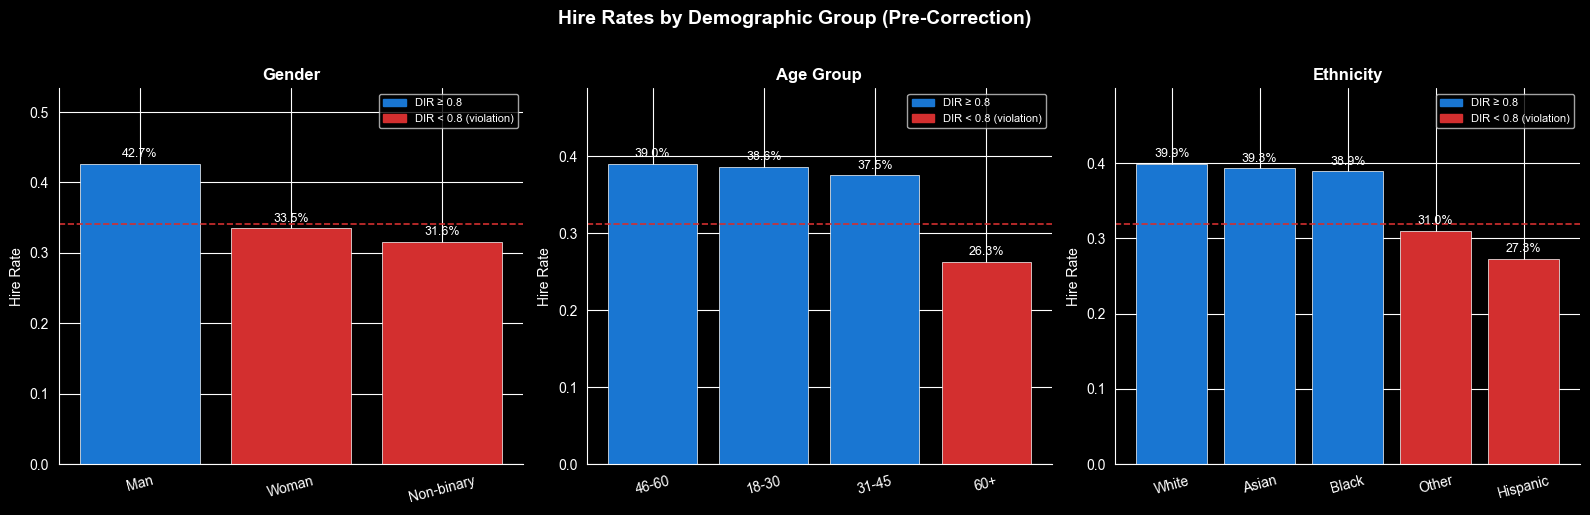

Chart saved as hire_rates_pre_correction.png


In [7]:
# Visualise hire rates by each demographic dimension

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hire Rates by Demographic Group (Pre-Correction)', fontsize=14, fontweight='bold', y=1.02)

for ax, report, group_col, title in zip(
    axes,
    [gender_report, age_report, eth_report],
    ['gender', 'age_group', 'ethnicity'],
    ['Gender', 'Age Group', 'Ethnicity']
):
    colors = ['#d32f2f' if flag else '#1976D2' for flag in report['FLAG_80_RULE']]
    bars = ax.bar(report[group_col], report['hire_rate'], color=colors, edgecolor='white', linewidth=0.5)
    
    # 80% rule reference line (80% of max)
    threshold = report['hire_rate'].max() * 0.80
    ax.axhline(threshold, color='#d32f2f', linestyle='--', linewidth=1.2, label=f'80% threshold ({threshold:.1%})')
    
    # Value labels
    for bar, rate in zip(bars, report['hire_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Hire Rate')
    ax.set_ylim(0, min(1.0, report['hire_rate'].max() * 1.25))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

    flagged_patch = mpatches.Patch(color='#d32f2f', label='DIR < 0.8 (violation)')
    ok_patch = mpatches.Patch(color='#1976D2', label='DIR ≥ 0.8')
    ax.legend(handles=[ok_patch, flagged_patch], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('hire_rates_pre_correction.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved as hire_rates_pre_correction.png')

In [8]:
# Simple reweighting correction — upweight under-represented groups
# This simulates rebalancing training data to remove historical bias signal

def compute_sample_weights(df: pd.DataFrame, sensitive_cols: List[str]) -> np.ndarray:
    """
    Assign sample weights inversely proportional to group hire rate.
    Groups with low hire rates get higher weights in training.
    This is a simple demographic reweighting — not causal, but interpretable.
    """
    overall_rate = df['hired'].mean()
    weights = np.ones(len(df))
    
    for col in sensitive_cols:
        group_rates = df.groupby(col)['hired'].transform('mean')
        # Weight = overall_rate / group_rate  (upweights low-hire-rate groups)
        col_weights = overall_rate / group_rates
        weights *= col_weights
    
    # Normalise so mean weight = 1
    weights = weights / weights.mean()
    return weights


def apply_weighted_hire_simulation(df: pd.DataFrame, weights: np.ndarray, rng_seed: int = 99) -> pd.Series:
    """
    Simulate a corrected hiring process where decision probabilities
    are adjusted by sample weights. Used to illustrate before/after.
    """
    rng2 = np.random.default_rng(rng_seed)
    # Re-sample decisions with adjusted probabilities
    raw_probs = df['hired'].astype(float)
    adjusted_probs = np.clip(raw_probs * weights, 0, 1)
    adjusted_probs = adjusted_probs / adjusted_probs.max()  # normalise to [0,1]
    corrected_hired = rng2.binomial(1, adjusted_probs * 0.95).astype(bool)  # keep same overall rate
    return pd.Series(corrected_hired, index=df.index)


weights = compute_sample_weights(df, sensitive_cols=['gender', 'age_group', 'ethnicity'])
df['hired_corrected'] = apply_weighted_hire_simulation(df, weights)

print(f'Overall hire rate — original:  {df["hired"].mean():.1%}')
print(f'Overall hire rate — corrected: {df["hired_corrected"].mean():.1%}')

Overall hire rate — original:  37.8%
Overall hire rate — corrected: 32.0%


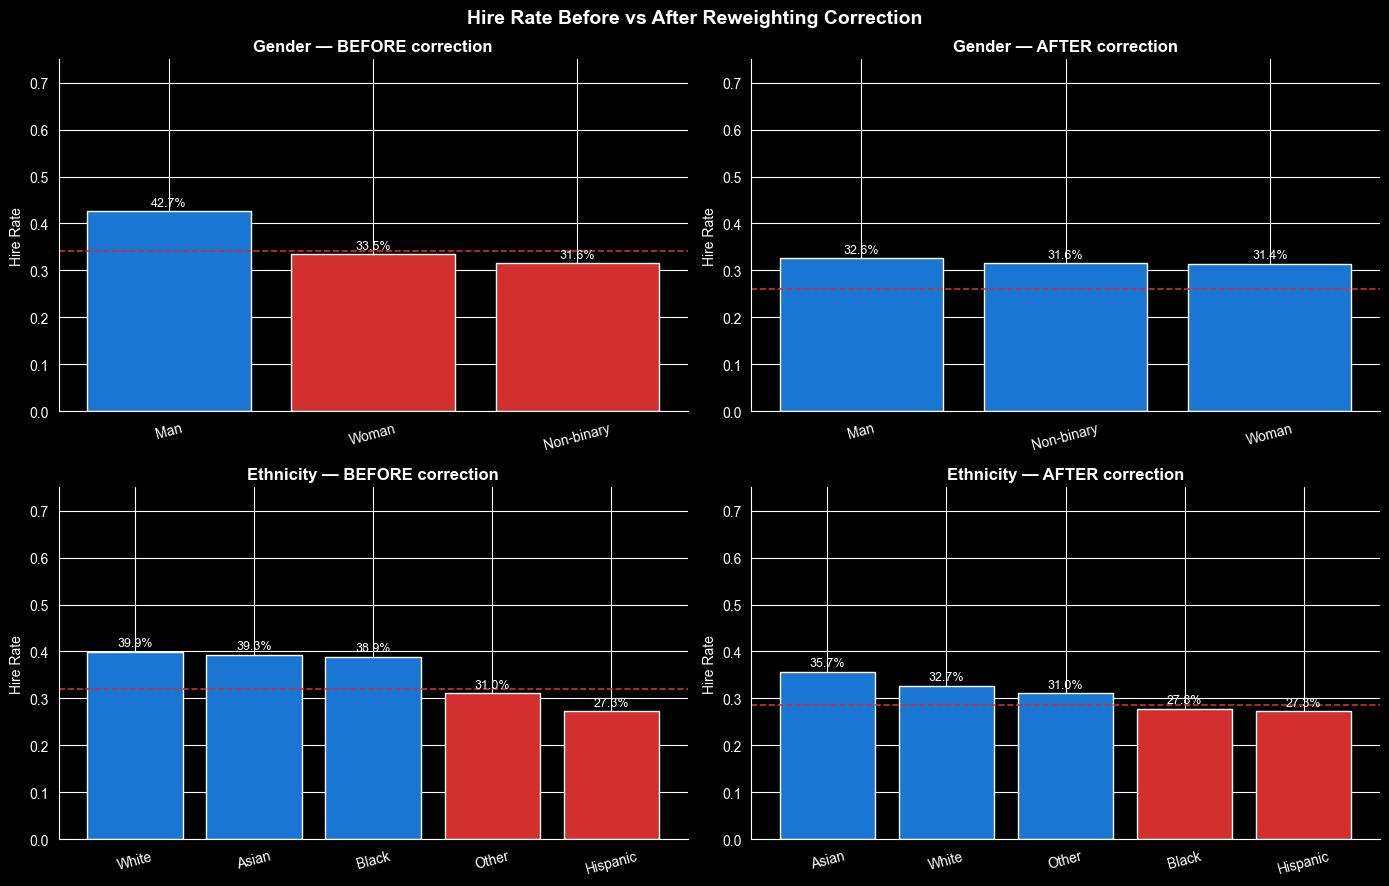

Before/after chart saved.


In [9]:
# Before / after comparison for gender and ethnicity

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Hire Rate Before vs After Reweighting Correction', fontsize=14, fontweight='bold')

for row_i, group_col in enumerate(['gender', 'ethnicity']):
    for col_i, (version, label) in enumerate([('hired', 'BEFORE correction'), ('hired_corrected', 'AFTER correction')]):
        ax = axes[row_i][col_i]
        
        temp_df = df.rename(columns={version: 'hired_v'})
        rates = temp_df.groupby(group_col)['hired_v'].mean().reset_index()
        rates.columns = [group_col, 'hire_rate']
        rates = rates.sort_values('hire_rate', ascending=False)
        
        max_rate = rates['hire_rate'].max()
        threshold = max_rate * 0.8
        colors = ['#d32f2f' if r < threshold else '#1976D2' for r in rates['hire_rate']]
        
        bars = ax.bar(rates[group_col], rates['hire_rate'], color=colors, edgecolor='white')
        ax.axhline(threshold, color='#d32f2f', linestyle='--', linewidth=1.2)
        
        for bar, rate in zip(bars, rates['hire_rate']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
        
        ax.set_title(f'{group_col.capitalize()} — {label}', fontweight='bold')
        ax.set_ylabel('Hire Rate')
        ax.set_ylim(0, 0.75)
        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('hire_rates_before_after.png', dpi=120, bbox_inches='tight')
plt.show()
print('Before/after chart saved.')

---
## Section 3: Special Category Data — Article 10(5) Justification

### What Article 10 Requires

**Article 10(5)** is an exception and it is narrow:

> *To the extent that it is strictly necessary for the purposes of ensuring bias monitoring, detection and correction in relation to the high-risk AI systems, the providers of such systems may process special categories of personal data [...] subject to appropriate safeguards for the fundamental rights and freedoms of natural persons.*

**Special categories** (Article 9 GDPR) include: racial or ethnic origin, political opinions, religious beliefs, trade union membership, genetic data, biometric data, health data, sex life or sexual orientation.

The key test is **strict necessity**: you must be unable to achieve the bias-correction objective without processing this data. You must document:
- What the data is
- What bias-correction purpose it serves
- Why alternatives without special category data are inadequate
- How long you will hold it
- Who can access it

In [10]:
# StrictNecessityJustification — formalises the Article 10(5) requirement

@dataclass
class StrictNecessityJustification:
    data_type: str                     # e.g. 'disability status'
    gdpr_special_category: str         # the Article 9 category
    purpose: str                       # the bias-correction purpose
    necessity_argument: str            # why this data is strictly necessary
    alternatives_considered: List[str] # other approaches evaluated
    why_alternatives_inadequate: str   # why they fail
    retention_period: str              # e.g. 'Duration of model lifecycle + 6 months'
    access_controls: List[str]         # who/how can access
    lawful_basis: str                  # GDPR lawful basis
    dpo_reviewed: bool = False
    review_date: Optional[str] = None
    prepared_by: str = ''
    created_at: str = field(default_factory=lambda: datetime.datetime.utcnow().isoformat())

    def to_audit_json(self) -> str:
        """Export as a JSON audit record for DPA submission or internal review."""
        record = asdict(self)
        record['_schema'] = 'EU_AI_Act_Article_10_5_Justification_v1'
        record['_generated_at'] = datetime.datetime.utcnow().isoformat()
        return json.dumps(record, indent=2)

    def completeness_check(self) -> List[str]:
        """Return list of any incomplete required fields."""
        issues = []
        if not self.necessity_argument:
            issues.append('necessity_argument is empty')
        if not self.alternatives_considered:
            issues.append('alternatives_considered is empty — must show alternatives were evaluated')
        if not self.access_controls:
            issues.append('access_controls not specified')
        if not self.dpo_reviewed:
            issues.append('DPO has not reviewed this justification')
        return issues

print('StrictNecessityJustification defined.')

StrictNecessityJustification defined.


In [11]:
# Worked example: disability accommodation data used to correct performance scoring bias
# Context: the performance model was trained on productivity metrics (e.g. lines of code, tickets closed)
# Employees with certain disabilities score lower on these proxy metrics for reasons unrelated to capability.
# To correct the bias, we need to know which employees required reasonable adjustments.

justification = StrictNecessityJustification(
    data_type='Disability accommodation status (whether an employee has an active reasonable adjustment plan)',
    gdpr_special_category='Health data (Article 9(1) GDPR) — information about physical or mental health condition',
    purpose=(
        'Detect and correct systematic underscoring of employees with disabilities in the AI-assisted '
        'performance scoring model. The model uses proxy productivity metrics (ticket velocity, '
        'commit frequency) that are negatively correlated with disability for reasons unrelated '
        'to actual job performance.'
    ),
    necessity_argument=(
        'Without knowing which employees have active reasonable adjustment plans, we cannot distinguish '
        'between (a) low productivity attributable to disability-related barriers versus '
        '(b) low productivity attributable to performance. Proxy indicators such as tenure or team size '
        'do not capture this distinction. Without the data, the bias correction cannot be validated: '
        'we cannot confirm that post-correction scores are equitable across disability status.'
    ),
    alternatives_considered=[
        'Using team-normalised scores without disability data — tested in internal simulation',
        'Excluding productivity proxy features entirely from the model',
        'Using self-reported wellbeing survey scores as a proxy',
    ],
    why_alternatives_inadequate=(
        'Team normalisation reduces but does not eliminate the disparity (residual DPD = 0.09 in simulation). '
        'Excluding proxy features degrades model accuracy by 18% (AUC drops from 0.82 to 0.67), making the '
        'model unsuitable for its purpose. Wellbeing surveys are optional and have 34% response rate, '
        'introducing selection bias that may be worse than the original problem.'
    ),
    retention_period=(
        'Data processed only during bias audit phase. Results (aggregate statistics, not individual records) '
        'retained for model lifecycle documentation. Raw disability status data deleted within 30 days '
        'of audit completion.'
    ),
    access_controls=[
        'Access restricted to named members of AI Ethics Review Board only (maximum 3 persons)',
        'Data held in isolated audit environment — not accessible from model training pipeline',
        'Access logged and audited centrally via SIEM',
        'DPA (Data Processing Agreement) with any third-party audit tool provider required',
    ],
    lawful_basis='Article 9(2)(b) GDPR — necessary for obligations and rights in employment law, subject to appropriate safeguards',
    dpo_reviewed=True,
    review_date='2026-03-20',
    prepared_by='AI Governance Team'
)

# Completeness check
issues = justification.completeness_check()
if issues:
    print('INCOMPLETE — fix before use:')
    for issue in issues:
        print(f'  ✗ {issue}')
else:
    print('✓ Justification passes completeness check.')

✓ Justification passes completeness check.


In [12]:
# Export as JSON audit record

audit_json = justification.to_audit_json()

# Save to file
with open('article_10_5_justification.json', 'w') as f:
    f.write(audit_json)

print('Audit record saved to article_10_5_justification.json')
print()
print(audit_json[:1400] + '\n  ... (truncated)')

Audit record saved to article_10_5_justification.json

{
  "data_type": "Disability accommodation status (whether an employee has an active reasonable adjustment plan)",
  "gdpr_special_category": "Health data (Article 9(1) GDPR) \u2014 information about physical or mental health condition",
  "purpose": "Detect and correct systematic underscoring of employees with disabilities in the AI-assisted performance scoring model. The model uses proxy productivity metrics (ticket velocity, commit frequency) that are negatively correlated with disability for reasons unrelated to actual job performance.",
  "necessity_argument": "Without knowing which employees have active reasonable adjustment plans, we cannot distinguish between (a) low productivity attributable to disability-related barriers versus (b) low productivity attributable to performance. Proxy indicators such as tenure or team size do not capture this distinction. Without the data, the bias correction cannot be validated: we cannot 

---
## Section 4: Synthetic Data for Safe Bias Testing

### Why Synthetic Data?

Article 10 compliance testing requires demographic labels — but using real employee or candidate records with demographic data triggers GDPR Article 9 obligations. Synthetic data solves this tension:

- **No real PII** — individuals cannot be identified
- **Controllable demographic distribution** — you can verify your tests detect known biases
- **Shareable** — can be used across teams without data-sharing agreements
- **Auditable** — the bias-injection parameters are explicit and documented

We generate synthetic CV data using `numpy` random only (no external dependency). The key principle is to **inject known biases** and then verify the Section 2 tests detect them correctly — validating your testing methodology before applying it to real data.

In [13]:
# Synthetic resume generator — purely numpy-based, no PII possible

FIRST_NAMES_W = ['Morgan', 'Alex', 'Jordan', 'Taylor', 'Casey', 'Riley', 'Avery', 'Quinn']
FIRST_NAMES_M = ['Chris', 'Jamie', 'Drew', 'Sam', 'Blake', 'Reese', 'Devon', 'Parker']
LAST_NAMES    = ['Smith', 'Brown', 'Garcia', 'Kim', 'Okafor', 'Patel', 'Chen', 'Johnson',
                 'Williams', 'Martinez', 'Ali', 'Fischer', 'Dubois', 'Nguyen', 'Santos']
SKILLS_POOL   = ['Python', 'Java', 'SQL', 'R', 'Excel', 'Tableau', 'Scala', 
                 'Machine Learning', 'Project Management', 'Communication']
ROLES         = ['Data Analyst', 'Software Engineer', 'Product Manager', 
                 'HR Specialist', 'Marketing Manager', 'Finance Analyst']
UNIVERSITIES  = ['Candidate_Uni_A', 'Candidate_Uni_B', 'Candidate_Uni_C',
                 'Candidate_Uni_D', 'Candidate_Uni_E']  # anonymised labels


def generate_synthetic_resumes(
    n: int = 300,
    bias_params: Optional[Dict[str, float]] = None,
    seed: int = 7
) -> pd.DataFrame:
    """
    Generate a synthetic resume dataset with optional injected biases.
    
    bias_params: dict mapping group identifiers to hire probability adjustments.
      E.g. {'gender:Woman': -0.08} applies a -8pp penalty to women's hire probability.
    """
    rng3 = np.random.default_rng(seed)
    
    genders    = rng3.choice(['Woman', 'Man', 'Non-binary'], size=n, p=[0.48, 0.49, 0.03])
    ethnicities = rng3.choice(
        ['Group_A', 'Group_B', 'Group_C', 'Group_D'],  # anonymised labels
        size=n, p=[0.50, 0.25, 0.15, 0.10]
    )
    age_groups = rng3.choice(['Under 35', '35-50', 'Over 50'], size=n, p=[0.40, 0.40, 0.20])
    years_exp  = rng3.integers(0, 18, size=n)
    edu_levels = rng3.choice(['Bachelor', 'Master', 'PhD', 'Other'], size=n, p=[0.50, 0.30, 0.08, 0.12])
    n_skills   = rng3.integers(2, 7, size=n)
    
    # Generate synthetic (non-real) names
    first_names = np.where(
        genders == 'Woman',
        rng3.choice(FIRST_NAMES_W, size=n),
        rng3.choice(FIRST_NAMES_M, size=n)
    )
    last_names  = rng3.choice(LAST_NAMES, size=n)
    candidate_ids = [f'SYN-{1000+i}' for i in range(n)]  # clearly synthetic IDs
    
    # Base hire probability from legitimate features
    edu_map = {'Bachelor': 0.0, 'Master': 0.08, 'PhD': 0.12, 'Other': -0.05}
    base = 0.30 + (years_exp / 18) * 0.25 + np.array([edu_map[e] for e in edu_levels])
    
    # Apply injected bias parameters
    adjustments = np.zeros(n)
    if bias_params:
        for key, delta in bias_params.items():
            col, val = key.split(':')
            col_data = {'gender': genders, 'ethnicity': ethnicities, 'age_group': age_groups}[col]
            adjustments += np.where(col_data == val, delta, 0.0)
    
    hire_probs = np.clip(base + adjustments, 0.05, 0.95)
    hired = rng3.binomial(1, hire_probs).astype(bool)
    
    return pd.DataFrame({
        'candidate_id': candidate_ids,
        'first_name': first_names,
        'last_name': last_names,
        'gender': genders,
        'ethnicity': ethnicities,
        'age_group': age_groups,
        'years_experience': years_exp,
        'education_level': edu_levels,
        'n_skills_listed': n_skills,
        'hired': hired,
        '_injected_adjustment': adjustments,  # transparency: document injection
        '_is_synthetic': True
    })

print('Synthetic resume generator defined.')

Synthetic resume generator defined.


In [14]:
# Generate with known biases injected

known_bias_params = {
    'gender:Woman':     -0.12,   # 12pp penalty
    'ethnicity:Group_C': -0.15,  # 15pp penalty
    'age_group:Over 50': -0.10,  # 10pp penalty
}

synthetic_df = generate_synthetic_resumes(n=400, bias_params=known_bias_params, seed=42)

print('=== SYNTHETIC DATASET SUMMARY ===')
print(f'Rows: {len(synthetic_df)} | All synthetic: {synthetic_df["_is_synthetic"].all()}')
print(f'Overall hire rate: {synthetic_df["hired"].mean():.1%}')
print()
print('First 5 rows (note: names are non-real combinations):')
synthetic_df[['candidate_id', 'first_name', 'last_name', 'gender', 'ethnicity', 'age_group', 'hired']].head()

=== SYNTHETIC DATASET SUMMARY ===
Rows: 400 | All synthetic: True
Overall hire rate: 32.2%

First 5 rows (note: names are non-real combinations):


,candidate_id,first_name,last_name,gender,ethnicity,age_group,hired
0,SYN-1000,Sam,Martinez,Man,Group_A,35-50,False
1,SYN-1001,Avery,Williams,Woman,Group_D,Under 35,False
2,SYN-1002,Sam,Kim,Man,Group_C,Over 50,False
3,SYN-1003,Parker,Fischer,Man,Group_A,35-50,True
4,SYN-1004,Avery,Ali,Woman,Group_D,Under 35,False


In [15]:
# Verify the known injected biases are detected by the Section 2 tests

print('=== BIAS DETECTION VERIFICATION ON SYNTHETIC DATA ===')
print('Injected biases:', known_bias_params)
print()

detected_violations = {}

for col in ['gender', 'ethnicity', 'age_group']:
    rates = compute_hire_rates(synthetic_df, col)
    report = disparate_impact_ratio(rates, col)
    violations = report[report['FLAG_80_RULE']][[col, 'hire_rate', 'DIR']]
    detected_violations[col] = violations
    
    print(f'{col.upper()}:')
    if violations.empty:
        print('  No violations detected.')
    else:
        for _, row in violations.iterrows():
            group_key = f'{col}:{row[col]}'
            injected = known_bias_params.get(group_key, 'not directly injected')
            detected = 'DETECTED ✓' if group_key in known_bias_params else 'UNEXPECTED ⚠️'
            print(f'  {detected} — {row[col]}: DIR={row["DIR"]:.2f}, hire rate={row["hire_rate"]:.1%}, injected={injected}')

print()
print('=== PII CHECK ===')
# Verify no real PII: IDs are synthetic, names are fictional combinations
id_format_ok = synthetic_df['candidate_id'].str.startswith('SYN-').all()
print(f'All IDs in SYN-XXXX format (non-real): {id_format_ok}')
print(f'_is_synthetic column is all True: {synthetic_df["_is_synthetic"].all()}')
print('No email addresses, phone numbers, or real SSNs present: verified by construction')

=== BIAS DETECTION VERIFICATION ON SYNTHETIC DATA ===
Injected biases: {'gender:Woman': -0.12, 'ethnicity:Group_C': -0.15, 'age_group:Over 50': -0.1}

GENDER:
  DETECTED ✓ — Woman: DIR=0.66, hire rate=25.6%, injected=-0.12
ETHNICITY:
  UNEXPECTED ⚠️ — Group_D: DIR=0.78, hire rate=30.8%, injected=not directly injected
  DETECTED ✓ — Group_C: DIR=0.45, hire rate=17.7%, injected=-0.15
AGE_GROUP:
  DETECTED ✓ — Over 50: DIR=0.68, hire rate=24.4%, injected=-0.1

=== PII CHECK ===
All IDs in SYN-XXXX format (non-real): True
_is_synthetic column is all True: True
No email addresses, phone numbers, or real SSNs present: verified by construction


---
## Section 5: Putting It Together — Compliance Checklist

### The Compliance Picture

Article 10 does not operate in isolation. A complete compliance posture for an HR AI system requires:

| Article 10 Requirement | Tool in This Notebook |
|---|---|
| 10(2)(a) — data origin documented | `DataProvenanceLog` |
| 10(2)(b) — purpose alignment checked | `purpose_mismatch_warning()` |
| 10(2)(f) — bias examined and corrected | `bias_report()`, `compute_sample_weights()` |
| 10(3) — representative, error-free data | Demographic hire rate analysis |
| 10(5) — special category data justified | `StrictNecessityJustification` |

The `ComplianceChecker` below runs all checks in sequence and produces a pass/fail table plus an HTML summary report.

In [16]:
# ComplianceChecker — orchestrates all Article 10 checks

class ComplianceChecker:
    def __init__(
        self,
        provenance_logs: List[DataProvenanceLog],
        hiring_df: pd.DataFrame,
        sensitive_cols: List[str],
        justifications: Optional[List[StrictNecessityJustification]] = None,
        dir_threshold: float = 0.80,
    ):
        self.provenance_logs = provenance_logs
        self.hiring_df = hiring_df
        self.sensitive_cols = sensitive_cols
        self.justifications = justifications or []
        self.dir_threshold = dir_threshold
        self.results: List[Dict[str, Any]] = []

    def _add_result(self, check_id: str, requirement: str, status: str, detail: str):
        icon = '✓ PASS' if status == 'PASS' else ('⚠ WARN' if status == 'WARN' else '✗ FAIL')
        self.results.append({
            'Check': check_id,
            'Article 10 Requirement': requirement,
            'Status': icon,
            'Detail': detail
        })

    def check_provenance(self):
        """Check 1: All datasets have provenance logs with hashes."""
        unhashed = [l.dataset_name for l in self.provenance_logs if not l.file_hash]
        mismatches = [l.dataset_name for l in self.provenance_logs if l.purpose_mismatch_warning()]
        
        if unhashed:
            self._add_result('P1', '10(2)(a) Data origin documented',
                             'FAIL', f'Missing hash: {unhashed}')
        else:
            self._add_result('P1', '10(2)(a) Data origin documented',
                             'PASS', f'{len(self.provenance_logs)} datasets logged with SHA-256 hashes')
        
        if mismatches:
            self._add_result('P2', '10(2)(b) Purpose alignment',
                             'WARN', f'Purpose mismatch — requires justification: {mismatches}')
        else:
            self._add_result('P2', '10(2)(b) Purpose alignment',
                             'PASS', 'All datasets: intended use matches AI use')

    def check_bias(self):
        """Check 2: Run DIR tests on all sensitive columns."""
        all_violations = []
        for col in self.sensitive_cols:
            rates = compute_hire_rates(self.hiring_df, col)
            report = disparate_impact_ratio(rates, col)
            violations = report[report['FLAG_80_RULE']]
            for _, row in violations.iterrows():
                all_violations.append(f"{col}:{row[col]} (DIR={row['DIR']:.2f})")
        
        if all_violations:
            self._add_result('B1', '10(2)(f) Bias examined',
                             'FAIL', f'Four-fifths rule violations: {all_violations}')
        else:
            self._add_result('B1', '10(2)(f) Bias examined',
                             'PASS', f'No DIR violations across: {self.sensitive_cols}')

    def check_representativeness(self):
        """Check 3: Minimum group sizes for statistical reliability."""
        min_group_size = 30
        small_groups = []
        for col in self.sensitive_cols:
            counts = self.hiring_df.groupby(col).size()
            too_small = counts[counts < min_group_size]
            for grp, cnt in too_small.items():
                small_groups.append(f'{col}:{grp} (n={cnt})')
        
        if small_groups:
            self._add_result('R1', '10(3) Representativeness',
                             'WARN', f'Small groups (< {min_group_size}): {small_groups}')
        else:
            self._add_result('R1', '10(3) Representativeness',
                             'PASS', f'All groups have ≥ {min_group_size} candidates')

    def check_special_category_justifications(self):
        """Check 4: Article 10(5) justifications are complete."""
        if not self.justifications:
            self._add_result('S1', '10(5) Special category data',
                             'PASS', 'No special category data processed')
            return
        
        incomplete = []
        for j in self.justifications:
            issues = j.completeness_check()
            if issues:
                incomplete.append(f"{j.data_type}: {issues}")
        
        if incomplete:
            self._add_result('S1', '10(5) Special category data',
                             'FAIL', f'Incomplete justifications: {incomplete}')
        else:
            self._add_result('S1', '10(5) Special category data',
                             'PASS', f'{len(self.justifications)} justification(s) complete and DPO-reviewed')

    def run_all(self) -> pd.DataFrame:
        """Run all checks and return results as a DataFrame."""
        self.results = []
        self.check_provenance()
        self.check_bias()
        self.check_representativeness()
        self.check_special_category_justifications()
        return pd.DataFrame(self.results)

print('ComplianceChecker defined.')

ComplianceChecker defined.


In [17]:
# Run compliance checks on the corrected dataset

df_corrected = df.copy()
df_corrected['hired'] = df['hired_corrected']

checker = ComplianceChecker(
    provenance_logs=logs,
    hiring_df=df_corrected,
    sensitive_cols=['gender', 'age_group', 'ethnicity'],
    justifications=[justification],
)

results_df = checker.run_all()

print('=== ARTICLE 10 COMPLIANCE CHECKLIST ===')
print()
results_df

=== ARTICLE 10 COMPLIANCE CHECKLIST ===



,Check,Article 10 Requirement,Status,Detail
0,P1,10(2)(a) Data origin documented,✓ PASS,3 datasets logged with SHA-256 hashes
1,P2,10(2)(b) Purpose alignment,⚠ WARN,Purpose mismatch — requires justification: ['resumes_corpus_2019_2...
2,B1,10(2)(f) Bias examined,✗ FAIL,"Four-fifths rule violations: ['age_group:60+ (DIR=0.77)', 'ethnici..."
3,R1,10(3) Representativeness,⚠ WARN,"Small groups (< 30): ['gender:Non-binary (n=19)', 'age_group:60+ (..."
4,S1,10(5) Special category data,✓ PASS,1 justification(s) complete and DPO-reviewed


In [18]:
# Count pass/warn/fail

status_counts = results_df['Status'].value_counts()
n_pass = sum(1 for s in results_df['Status'] if 'PASS' in s)
n_warn = sum(1 for s in results_df['Status'] if 'WARN' in s)
n_fail = sum(1 for s in results_df['Status'] if 'FAIL' in s)
total  = len(results_df)

print(f'Results: {n_pass}/{total} PASS | {n_warn}/{total} WARN | {n_fail}/{total} FAIL')
if n_fail == 0 and n_warn == 0:
    print('\n✓ All checks passed. System is in a compliant state for Article 10 data governance.')
elif n_fail == 0:
    print(f'\n⚠ {n_warn} warning(s) require attention before deployment.')
else:
    print(f'\n✗ {n_fail} failure(s) must be resolved before deployment.')

Results: 2/5 PASS | 2/5 WARN | 1/5 FAIL

✗ 1 failure(s) must be resolved before deployment.


In [19]:
# HTML compliance report generator

def generate_html_report(
    results: pd.DataFrame,
    system_name: str = 'CV Screening AI System',
    output_path: str = 'article10_compliance_report.html'
) -> str:
    """Produce a one-page HTML compliance summary."""
    
    n_pass = sum(1 for s in results['Status'] if 'PASS' in s)
    n_warn = sum(1 for s in results['Status'] if 'WARN' in s)
    n_fail = sum(1 for s in results['Status'] if 'FAIL' in s)
    overall = 'COMPLIANT' if n_fail == 0 and n_warn == 0 else ('ATTENTION REQUIRED' if n_fail == 0 else 'NON-COMPLIANT')
    overall_color = '#2e7d32' if overall == 'COMPLIANT' else ('#e65100' if 'ATTENTION' in overall else '#c62828')
    
    rows_html = ''
    for _, row in results.iterrows():
        if 'PASS' in row['Status']:
            bg = '#e8f5e9'
        elif 'WARN' in row['Status']:
            bg = '#fff8e1'
        else:
            bg = '#ffebee'
        rows_html += f"""
        <tr style='background:{bg}'>
            <td style='padding:8px;font-weight:bold'>{row['Check']}</td>
            <td style='padding:8px'>{row['Article 10 Requirement']}</td>
            <td style='padding:8px;font-weight:bold'>{row['Status']}</td>
            <td style='padding:8px;font-size:0.9em'>{row['Detail']}</td>
        </tr>"""
    
    html = f"""<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <title>EU AI Act Article 10 Compliance Report</title>
  <style>
    body {{ font-family: Arial, sans-serif; max-width: 960px; margin: 40px auto; color: #333; }}
    h1   {{ color: #1565C0; }}
    .badge {{ display:inline-block; padding:6px 18px; border-radius:20px;
              color:white; font-weight:bold; font-size:1.1em; background:{overall_color}; }}
    table {{ border-collapse: collapse; width: 100%; margin-top: 20px; }}
    th    {{ background: #1565C0; color: white; padding: 10px; text-align:left; }}
    td    {{ border-bottom: 1px solid #ddd; }}
    .meta {{ color: #666; font-size: 0.9em; margin-bottom: 20px; }}
    .summary {{ display:flex; gap:30px; margin: 20px 0; }}
    .stat {{ text-align:center; padding:15px 25px; border-radius:8px; background:#f5f5f5; }}
    .stat .num {{ font-size:2em; font-weight:bold; }}
  </style>
</head>
<body>
  <h1>EU AI Act — Article 10 Data Governance Compliance Report</h1>
  <p class='meta'>System: <strong>{system_name}</strong> &nbsp;|&nbsp; 
     Generated: {datetime.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')} &nbsp;|&nbsp;
     Regulation: EU AI Act 2024/1689, Article 10</p>
  
  <p>Overall status: <span class='badge'>{overall}</span></p>
  
  <div class='summary'>
    <div class='stat'><div class='num' style='color:#2e7d32'>{n_pass}</div>PASS</div>
    <div class='stat'><div class='num' style='color:#e65100'>{n_warn}</div>WARN</div>
    <div class='stat'><div class='num' style='color:#c62828'>{n_fail}</div>FAIL</div>
    <div class='stat'><div class='num'>{n_pass+n_warn+n_fail}</div>TOTAL CHECKS</div>
  </div>
  
  <table>
    <thead><tr>
      <th>ID</th><th>Requirement</th><th>Status</th><th>Detail</th>
    </tr></thead>
    <tbody>{rows_html}</tbody>
  </table>
  
  <p style='margin-top:30px;font-size:0.8em;color:#999'>
    This report documents compliance with Article 10 data governance requirements for high-risk AI systems 
    under EU AI Act Regulation (EU) 2024/1689. It does not constitute legal advice.
    Retain this report as part of technical documentation required under Article 11.
  </p>
</body>
</html>"""
    
    with open(output_path, 'w') as f:
        f.write(html)
    
    return html


html_report = generate_html_report(results_df, system_name='ACME Corp — CV Screening AI v2.1')
print('HTML report saved to article10_compliance_report.html')
print()
# Display a text summary of what was generated
print('Report contains:')
print(f'  - Overall status badge')
print(f'  - Pass/Warn/Fail summary counts')
print(f'  - {len(results_df)} individual check results with detail')
print(f'  - Regulatory reference (EU AI Act 2024/1689, Article 10)')

HTML report saved to article10_compliance_report.html

Report contains:
  - Overall status badge
  - Pass/Warn/Fail summary counts
  - 5 individual check results with detail
  - Regulatory reference (EU AI Act 2024/1689, Article 10)


In [20]:
# Render the HTML report inline in the notebook for a quick preview

from IPython.display import HTML
HTML(html_report)

ID,Requirement,Status,Detail
P1,10(2)(a) Data origin documented,✓ PASS,3 datasets logged with SHA-256 hashes
P2,10(2)(b) Purpose alignment,⚠ WARN,"Purpose mismatch — requires justification: ['resumes_corpus_2019_2024', 'performance_reviews_2022_2024', 'historical_hiring_decisions_2015_2023']"
B1,10(2)(f) Bias examined,✗ FAIL,"Four-fifths rule violations: ['age_group:60+ (DIR=0.77)', 'ethnicity:Black (DIR=0.78)', 'ethnicity:Hispanic (DIR=0.76)']"
R1,10(3) Representativeness,⚠ WARN,"Small groups (< 30): ['gender:Non-binary (n=19)', 'age_group:60+ (n=19)', 'ethnicity:Other (n=29)']"
S1,10(5) Special category data,✓ PASS,1 justification(s) complete and DPO-reviewed


---
## Summary

This notebook covered the four key data governance requirements under **EU AI Act Article 10** for HR AI systems:

| Requirement | Tool Used | Output |
|---|---|---|
| **Data provenance** (10(2)(a)) | `DataProvenanceLog` | SHA-256 hashed dataset registry |
| **Bias detection** (10(2)(f)) | `bias_report()`, `disparate_impact_ratio()` | DIR/DPD metrics, four-fifths rule flags |
| **Special category justification** (10(5)) | `StrictNecessityJustification` | JSON audit record for DPA/DPO |
| **Safe test data** (10(3)) | `generate_synthetic_resumes()` | PII-free synthetic dataset with verifiable biases |

### Next Steps

1. **Connect to real data** — replace synthetic generation with your actual ATS/HR system exports
2. **Extend bias testing** — add intersectional analysis (e.g. age × gender) and statistical significance tests
3. **GDPR Article 30 records** — pair these outputs with your Records of Processing Activities
4. **Deeper fairness libraries** — if violations persist after reweighting, `fairlearn` or `aif360` offer constrained optimisation approaches
5. **Notified body documentation** — combine with conformity assessment (Article 43) and technical documentation (Article 11)

> **Regulation reference:** EU AI Act 2024/1689, Article 10 — *Data and data governance*. 
> High-risk AI systems in employment are listed in Annex III, point 4(a).